In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.special import logit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, DotProduct
import numpy as np
import matplotlib.pyplot as plt
from sklearn_extra.cluster import KMedoids
import matplotlib as mpl


In [30]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class GaussianProcessWithPrior:
    def __init__(self, kernel=None, normalize_y=False, n_restarts_optimizer=10):
        self.gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=normalize_y, n_restarts_optimizer=n_restarts_optimizer)
        self.train_prior = None  

    def fit(self, X, y, train_prior):
        """Fits the model to residuals (y - train_prior)."""
        if train_prior.shape != y.shape:
            raise ValueError("Shape mismatch between 'train_prior' and 'y'")
        self.train_prior = train_prior
        residuals = y - train_prior
        self.gpr.fit(X, residuals)

    def predict(self, X, predict_prior, return_std=True):
        """Predicts using the GP model with the prior added back."""
        if predict_prior.shape[0] != X.shape[0]:
            raise ValueError("Shape mismatch between 'predict_prior' and 'X'")

        mu, std = self.gpr.predict(X, return_std=True)
        mu_with_prior = mu + predict_prior

        if return_std:
            return sigmoid(mu_with_prior), std
        return sigmoid(mu_with_prior)

In [63]:
combined_df = pd.read_csv("combined_solidus_karma_results.csv", dtype={'Explanation': str})
combined_df

,Source,G,C,R,Vab,Prior,Truth,Explanation
0,Grid,100000.000000,0.15,0.012,0.408627,0,NaN,NaN
1,Grid,109854.114199,0.15,0.012,0.408627,0,NaN,NaN
2,Grid,120679.264064,0.15,0.012,0.408627,0,NaN,NaN
3,Grid,132571.136559,0.15,0.012,0.408627,0,NaN,NaN
4,Grid,145634.847750,0.15,0.012,0.408627,0,NaN,NaN
...,...,...,...,...,...,...,...,...
125048,Karma,100000.000000,0.19,0.030,0.630127,0,0.0,Cellular (not run)
125049,Karma,100000.000000,0.19,0.060,0.630127,0,0.0,Cellular (not run)
125050,Karma,100000.000000,0.19,0.120,0.630127,0,0.0,Cellular
125051,Karma,100000.000000,0.19,0.300,0.630127,0,0.0,Cellular (ish)


In [64]:
combined_df['log10(G)'] = np.log10(combined_df['G'])

In [65]:
combined_df

,Source,G,C,R,Vab,Prior,Truth,Explanation,log10(G)
0,Grid,100000.000000,0.15,0.012,0.408627,0,NaN,NaN,5.000000
1,Grid,109854.114199,0.15,0.012,0.408627,0,NaN,NaN,5.040816
2,Grid,120679.264064,0.15,0.012,0.408627,0,NaN,NaN,5.081633
3,Grid,132571.136559,0.15,0.012,0.408627,0,NaN,NaN,5.122449
4,Grid,145634.847750,0.15,0.012,0.408627,0,NaN,NaN,5.163265
...,...,...,...,...,...,...,...,...,...
125048,Karma,100000.000000,0.19,0.030,0.630127,0,0.0,Cellular (not run),5.000000
125049,Karma,100000.000000,0.19,0.060,0.630127,0,0.0,Cellular (not run),5.000000
125050,Karma,100000.000000,0.19,0.120,0.630127,0,0.0,Cellular,5.000000
125051,Karma,100000.000000,0.19,0.300,0.630127,0,0.0,Cellular (ish),5.000000


(array([26.,  7.,  4.,  3.,  2.,  2.,  2.,  1.,  1.,  2.]),
 array([  100000.,  1090000.,  2080000.,  3070000.,  4060000.,  5050000.,
         6040000.,  7030000.,  8020000.,  9010000., 10000000.]),
 <BarContainer object of 10 artists>)

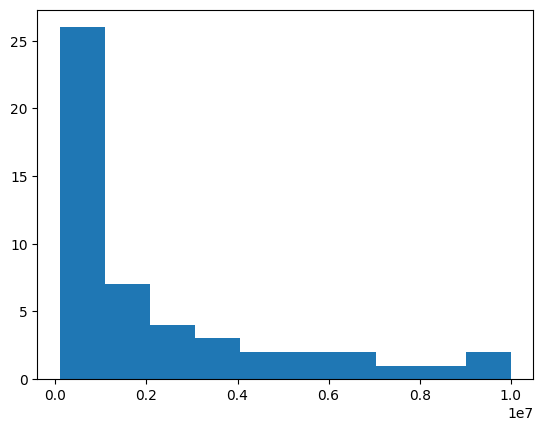

In [61]:
testlog2 = np.linspace(5,7)
testlog2 = 10**testlog2
plt.hist(testlog2)

(array([26.,  7.,  4.,  3.,  2.,  2.,  2.,  1.,  1.,  2.]),
 array([  100000.,  1090000.,  2080000.,  3070000.,  4060000.,  5050000.,
         6040000.,  7030000.,  8020000.,  9010000., 10000000.]),
 <BarContainer object of 10 artists>)

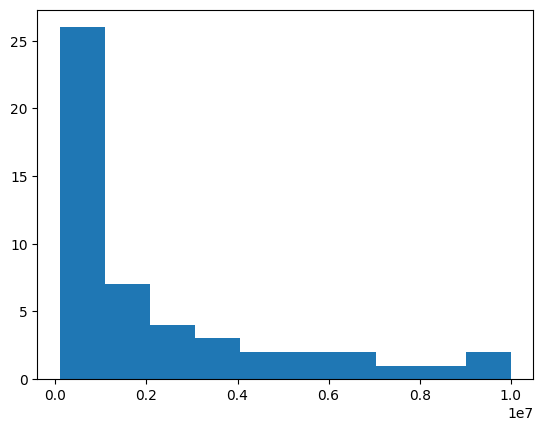

In [58]:
testlog = np.logspace(5,7)
plt.hist(testlog)

(array([12517., 12500., 12500., 12500., 12500., 12518., 12500., 12500.,
        12500., 12518.]),
 array([5. , 5.2, 5.4, 5.6, 5.8, 6. , 6.2, 6.4, 6.6, 6.8, 7. ]),
 <BarContainer object of 10 artists>)

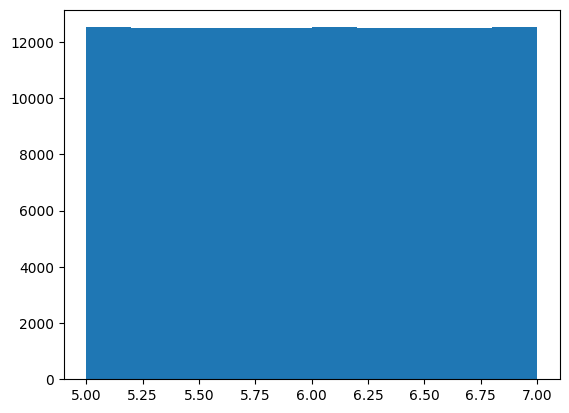

In [66]:
logG = combined_df['log10(G)'].values
plt.hist(logG)

In [31]:
combined_df = pd.read_csv("combined_solidus_karma_results.csv", dtype={'Explanation': str})
prior_scaler = MinMaxScaler(feature_range=(logit(.4), logit(.6)))
combined_df["Prior_Scaled"] = prior_scaler.fit_transform(combined_df[["Prior"]])
truth_scaler = MinMaxScaler(feature_range=(-5, 5))
combined_df["Truth_Scaled"] = truth_scaler.fit_transform(combined_df[["Truth"]])

train_df = (combined_df[combined_df["Source"] == "Karma"]).copy()
grid_df = (combined_df[combined_df["Source"] == "Grid"]).copy()

X_scaler = MinMaxScaler(feature_range=(0,1))
grid_df.loc[:,["R", "G", "C"]] = X_scaler.fit_transform(grid_df[["R", "G", "C"]])
train_df.loc[:,["R", "G", "C"]] = X_scaler.transform(train_df[["R", "G", "C"]])

X_train = train_df[["R", "G", "C"]].values
y_train = train_df["Truth_Scaled"].values
train_prior = train_df["Prior_Scaled"].values

In [37]:
gp = GaussianProcessWithPrior(kernel=Matern(nu=.5,length_scale=[1,1,1],length_scale_bounds=(.05,1)), n_restarts_optimizer=10,normalize_y=False)
gp.fit(X_train, y_train, train_prior)

In [39]:
gp.gpr.kernel_.length_scale

array([0.1756759 , 0.89638454, 0.87625045])

In [26]:
combined_df

,Source,G,C,R,Vab,Prior,Truth,Explanation,Prior_Scaled,Truth_Scaled
0,Grid,100000.000000,0.15,0.012,0.408627,0,NaN,NaN,-0.405465,NaN
1,Grid,302040.816327,0.15,0.012,0.408627,0,NaN,NaN,-0.405465,NaN
2,Grid,504081.632653,0.15,0.012,0.408627,0,NaN,NaN,-0.405465,NaN
3,Grid,706122.448980,0.15,0.012,0.408627,0,NaN,NaN,-0.405465,NaN
4,Grid,908163.265306,0.15,0.012,0.408627,0,NaN,NaN,-0.405465,NaN
...,...,...,...,...,...,...,...,...,...,...
125048,Karma,100000.000000,0.19,0.030,0.630127,0,0.0,Cellular (not run),-0.405465,-5.0
125049,Karma,100000.000000,0.19,0.060,0.630127,0,0.0,Cellular (not run),-0.405465,-5.0
125050,Karma,100000.000000,0.19,0.120,0.630127,0,0.0,Cellular,-0.405465,-5.0
125051,Karma,100000.000000,0.19,0.300,0.630127,0,0.0,Cellular (ish),-0.405465,-5.0


In [5]:
df_grid = pd.read_csv('grid_df_iteration_2.csv')
df_grid

,Source,G,C,R,Vab,Prior,Truth,Explanation,log10(G),Prior_Scaled,Truth_Scaled,Predicted_Probability,Std_Dev,H
0,Grid,1.000000e+05,0.15,0.012,0.408627,0,NaN,NaN,5.000000,-0.405465,NaN,0.006693,0.000010,0.057967
1,Grid,1.098541e+05,0.15,0.012,0.408627,0,NaN,NaN,5.040816,-0.405465,NaN,0.006754,0.234475,0.058409
2,Grid,1.206793e+05,0.15,0.012,0.408627,0,NaN,NaN,5.081633,-0.405465,NaN,0.006816,0.321541,0.058855
3,Grid,1.325711e+05,0.15,0.012,0.408627,0,NaN,NaN,5.122449,-0.405465,NaN,0.006878,0.382076,0.059302
4,Grid,1.456348e+05,0.15,0.012,0.408627,0,NaN,NaN,5.163265,-0.405465,NaN,0.006940,0.428177,0.059746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,Grid,6.866488e+06,0.19,0.600,0.630127,0,NaN,NaN,6.836735,-0.405465,NaN,0.992373,0.435058,0.064613
124996,Grid,7.543120e+06,0.19,0.600,0.630127,0,NaN,NaN,6.877551,-0.405465,NaN,0.992584,0.387274,0.063126
124997,Grid,8.286428e+06,0.19,0.600,0.630127,0,NaN,NaN,6.918367,-0.405465,NaN,0.992812,0.324818,0.061516
124998,Grid,9.102982e+06,0.19,0.600,0.630127,0,NaN,NaN,6.959184,-0.405465,NaN,0.993053,0.235808,0.059793


In [ ]:
top = 2.5
N = 10
X_labels = ["R", "log10(G)", "C"]

H = df_grid['H'].values
number_top_candidates = int(top/100*len(df_grid))
id_top_candidates_df_grid = np.argpartition(H, -number_top_candidates)[-number_top_candidates:]
df_grid_candidates = df_grid.loc[id_top_candidates_df_grid,:]
df_grid_candidates_array = df_grid_candidates.loc[:,X_labels].values
kmedoids = KMedoids(n_clusters=N).fit(df_grid_candidates_array)
id_medoids_candidates = kmedoids.medoid_indices_
cluster_labels = kmedoids.labels_
cmap = mpl.colormaps['Set3']
cluster_colors = [cmap(label) for label in cluster_labels]

df_grid_candidates['cluster_color'] = cluster_colors
idmax_cluster = df_grid_candidates.groupby('cluster_color')['H'].idxmax().values
df_grid_candidates_medoids = df_grid_candidates.iloc[id_medoids_candidates,:]

In [15]:
idmax_cluster = df_grid_candidates.groupby('cluster_color')['H'].idxmax().values

In [20]:
df_grid_candidates.loc[idmax_cluster,:]

,Source,G,C,R,Vab,Prior,Truth,Explanation,log10(G),Prior_Scaled,Truth_Scaled,Predicted_Probability,Std_Dev,H,cluster_color
31213,Grid,3.393222e+05,0.159796,0.300,0.460869,0,NaN,NaN,5.530612,-0.405465,NaN,0.501183,0.588513,0.999996,"(0.5019607843137255, 0.6941176470588235, 0.827..."
66316,Grid,4.498433e+05,0.171224,0.324,0.532449,0,NaN,NaN,5.653061,-0.405465,NaN,0.502524,0.642239,0.999982,"(0.5529411764705883, 0.8274509803921568, 0.780..."
106285,Grid,2.682696e+06,0.184286,0.312,0.600521,0,NaN,NaN,6.428571,-0.405465,NaN,0.499192,0.617321,0.999998,"(0.7019607843137254, 0.8705882352941177, 0.411..."
63850,Grid,1.000000e+05,0.170408,0.336,0.519790,0,NaN,NaN,5.000000,-0.405465,NaN,0.499984,0.736097,1.000000,"(0.7372549019607844, 0.5019607843137255, 0.741..."
93828,Grid,1.389495e+06,0.180204,0.324,0.586243,0,NaN,NaN,6.142857,-0.405465,NaN,0.499401,0.664154,0.999999,"(0.7450980392156863, 0.7294117647058823, 0.854..."
123693,Grid,5.689866e+06,0.190000,0.288,0.630127,0,NaN,NaN,6.755102,-0.405465,NaN,0.500080,0.525006,1.000000,"(0.8509803921568627, 0.8509803921568627, 0.850..."
36182,Grid,2.023590e+06,0.161429,0.288,0.472093,0,NaN,NaN,6.306122,-0.405465,NaN,0.499545,0.596730,0.999999,"(0.984313725490196, 0.5019607843137255, 0.4470..."
8598,Grid,9.102982e+06,0.152449,0.264,0.418579,0,NaN,NaN,6.959184,-0.405465,NaN,0.498367,0.704092,0.999992,"(0.9882352941176471, 0.803921568627451, 0.8980..."
53771,Grid,7.196857e+05,0.167143,0.312,0.507432,0,NaN,NaN,5.857143,-0.405465,NaN,0.498729,0.486821,0.999995,"(0.9921568627450981, 0.7058823529411765, 0.384..."
81359,Grid,2.329952e+05,0.176122,0.336,0.558699,0,NaN,NaN,5.367347,-0.405465,NaN,0.500601,0.720911,0.999999,"(1.0, 1.0, 0.7019607843137254, 1.0)"


In [3]:
med = pd.read_csv('grid_df_candidates_medoids_iteration_1.csv')
med

,Source,G,C,R,Vab,Prior,Truth,Explanation,log10(G),Prior_Scaled,Truth_Scaled,Predicted_Probability,Std_Dev,H,cluster_color
0,Grid,3.556480e+06,0.169592,0.252,0.519790,0,NaN,NaN,6.551020,-0.405465,NaN,0.528375,0.721085,0.997676,"(0.5529411764705883, 0.8274509803921568, 0.780..."
1,Grid,4.094915e+05,0.171224,0.408,0.532449,0,NaN,NaN,5.612245,-0.405465,NaN,0.527262,0.879601,0.997854,"(1.0, 1.0, 0.7019607843137254, 1.0)"
2,Grid,7.906043e+05,0.159796,0.312,0.460869,0,NaN,NaN,5.897959,-0.405465,NaN,0.480065,0.548411,0.998853,"(0.7450980392156863, 0.7294117647058823, 0.854..."
3,Grid,8.685114e+05,0.185102,0.396,0.600521,0,NaN,NaN,5.938776,-0.405465,NaN,0.440953,0.863243,0.989916,"(0.984313725490196, 0.5019607843137255, 0.4470..."
4,Grid,1.264855e+06,0.174490,0.372,0.545416,0,NaN,NaN,6.102041,-0.405465,NaN,0.483878,0.805422,0.999250,"(0.5019607843137255, 0.6941176470588235, 0.827..."
5,Grid,2.120951e+05,0.154082,0.372,0.428773,0,NaN,NaN,5.326531,-0.405465,NaN,0.469047,0.843684,0.997234,"(0.9921568627450981, 0.7058823529411765, 0.384..."
6,Grid,3.556480e+06,0.183469,0.276,0.600521,0,NaN,NaN,6.551020,-0.405465,NaN,0.513603,0.657925,0.999466,"(0.7019607843137254, 0.8705882352941177, 0.411..."
7,Grid,1.757511e+05,0.164694,0.408,0.495368,0,NaN,NaN,5.244898,-0.405465,NaN,0.474092,0.887592,0.998062,"(0.9882352941176471, 0.803921568627451, 0.8980..."
8,Grid,1.930698e+05,0.182653,0.432,0.600521,0,NaN,NaN,5.285714,-0.405465,NaN,0.530730,0.904528,0.997274,"(0.8509803921568627, 0.8509803921568627, 0.850..."
9,Grid,4.291934e+06,0.156531,0.228,0.439215,0,NaN,NaN,6.632653,-0.405465,NaN,0.554730,0.769964,0.991340,"(0.7372549019607844, 0.5019607843137255, 0.741..."


In [4]:
top = pd.read_csv('grid_df_candidates_top_iteration_1.csv')
top

,Source,G,C,R,Vab,Prior,Truth,Explanation,log10(G),Prior_Scaled,Truth_Scaled,Predicted_Probability,Std_Dev,H,cluster_color
0,Grid,1.151395e+06,0.177755,0.384,0.572305,0,NaN,NaN,6.061224,-0.405465,NaN,0.499709,0.836074,1.0,"(0.5019607843137255, 0.6941176470588235, 0.827..."
1,Grid,2.222996e+06,0.167143,0.300,0.507432,0,NaN,NaN,6.346939,-0.405465,NaN,0.500051,0.593795,1.0,"(0.5529411764705883, 0.8274509803921568, 0.780..."
2,Grid,2.947052e+06,0.183469,0.312,0.600521,0,NaN,NaN,6.469388,-0.405465,NaN,0.499892,0.633909,1.0,"(0.7019607843137254, 0.8705882352941177, 0.411..."
3,Grid,2.442053e+06,0.151633,0.228,0.418579,0,NaN,NaN,6.387755,-0.405465,NaN,0.499975,0.775263,1.0,"(0.7372549019607844, 0.5019607843137255, 0.741..."
4,Grid,7.196857e+05,0.165510,0.372,0.495368,0,NaN,NaN,5.857143,-0.405465,NaN,0.499885,0.808003,1.0,"(0.7450980392156863, 0.7294117647058823, 0.854..."
5,Grid,3.727594e+05,0.183469,0.420,0.600521,0,NaN,NaN,5.571429,-0.405465,NaN,0.500038,0.894210,1.0,"(0.8509803921568627, 0.8509803921568627, 0.850..."
6,Grid,6.551286e+05,0.182653,0.408,0.600521,0,NaN,NaN,5.816327,-0.405465,NaN,0.500054,0.879953,1.0,"(0.984313725490196, 0.5019607843137255, 0.4470..."
7,Grid,3.393222e+05,0.160612,0.384,0.472093,0,NaN,NaN,5.530612,-0.405465,NaN,0.499871,0.848595,1.0,"(0.9882352941176471, 0.803921568627451, 0.8980..."
8,Grid,1.098541e+05,0.157347,0.408,0.449912,0,NaN,NaN,5.040816,-0.405465,NaN,0.500160,0.900345,1.0,"(0.9921568627450981, 0.7058823529411765, 0.384..."
9,Grid,6.551286e+05,0.167959,0.384,0.507432,0,NaN,NaN,5.816327,-0.405465,NaN,0.499930,0.837525,1.0,"(1.0, 1.0, 0.7019607843137254, 1.0)"


In [10]:
Cmed

0    (0.5529411764705883, 0.8274509803921568, 0.780...
1                  (1.0, 1.0, 0.7019607843137254, 1.0)
2    (0.7450980392156863, 0.7294117647058823, 0.854...
3    (0.984313725490196, 0.5019607843137255, 0.4470...
4    (0.5019607843137255, 0.6941176470588235, 0.827...
5    (0.9921568627450981, 0.7058823529411765, 0.384...
6    (0.7019607843137254, 0.8705882352941177, 0.411...
7    (0.9882352941176471, 0.803921568627451, 0.8980...
8    (0.8509803921568627, 0.8509803921568627, 0.850...
9    (0.7372549019607844, 0.5019607843137255, 0.741...
Name: cluster_color, dtype: object

In [19]:
X[0]

'0.5529411764705883'

In [20]:
X = '(0.5529411764705883, 0.8274509803921568, 0.7803921568627451, 1.0)'[1:-1].split(',')
[float(i) for i in X]

[0.5529411764705883, 0.8274509803921568, 0.7803921568627451, 1.0]

In [12]:
import matplotlib.colors as mcolors
mcolors.to_rgba('(0.5529411764705883, 0.8274509803921568, 0.7803921568627451, 1.0)')

ValueError: Invalid RGBA argument: '(0.5529411764705883, 0.8274509803921568, 0.7803921568627451, 1.0)'

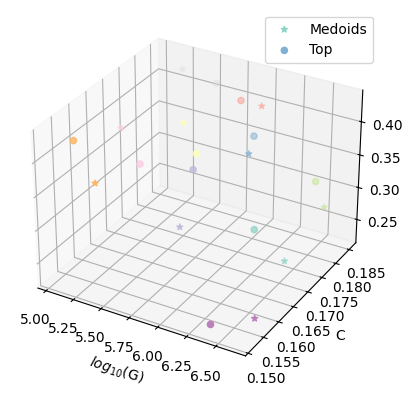

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

Xmed = med['log10(G)']
Ymed = med['C']
Zmed = med['R']
Cmed = med['cluster_color'].values
CmedNum = []
for i in Cmed:
    x = i[1:-1].split(',')
    CmedNum.append([float(j) for j in x])


Xtop = top['log10(G)']
Ytop = top['C']
Ztop = top['R']
Ctop = top['cluster_color'].values
CtopNum = []
for i in Ctop:
    x = i[1:-1].split(',')
    CtopNum.append([float(j) for j in x])

ax.scatter(Xmed, Ymed, Zmed, color=CmedNum, marker='*', label='Medoids')
ax.scatter(Xtop, Ytop, Ztop, color=CtopNum, label='Top')

ax.set_xlabel(r'$log_{10}$(G)')
ax.set_ylabel('C')
ax.set_zlabel('R')

ax.legend()

plt.show()